In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Bài 1

## a)

In [9]:
def dft(x : np.ndarray):
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    X = W @ x
    return X

## b)

In [34]:
def idft(x : np.ndarray):
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(2j * np.pi * k * n / N)
    X = W @ x
    return X

## c)

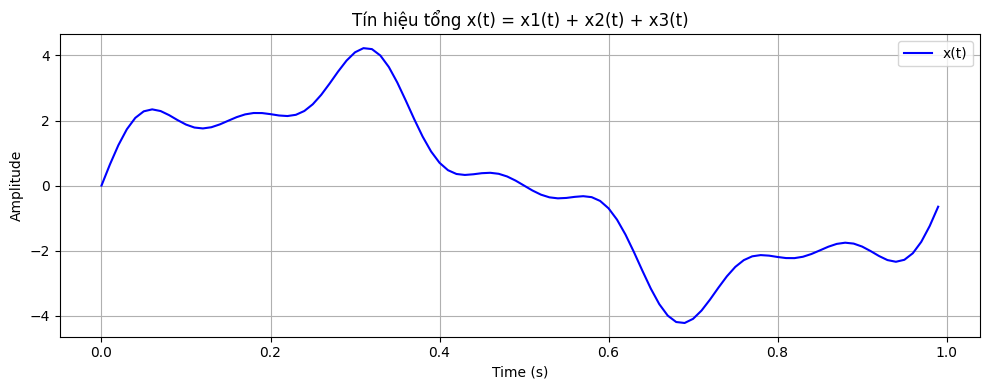

In [11]:
fs = 100
T = 1
t = np.linspace(0, T, int(fs*T), endpoint=False)

x1 = 3 * np.sin(2 * np.pi * 1 * t)
x2 = 1 * np.sin(2 * np.pi * 4 * t)
x3 = 0.5 * np.sin(2 * np.pi * 7 * t)

x = x1 + x2 + x3

plt.figure(figsize=(10, 4))
plt.plot(t, x, label='x(t)', color='blue')
plt.title('Tín hiệu tổng x(t) = x1(t) + x2(t) + x3(t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# d)

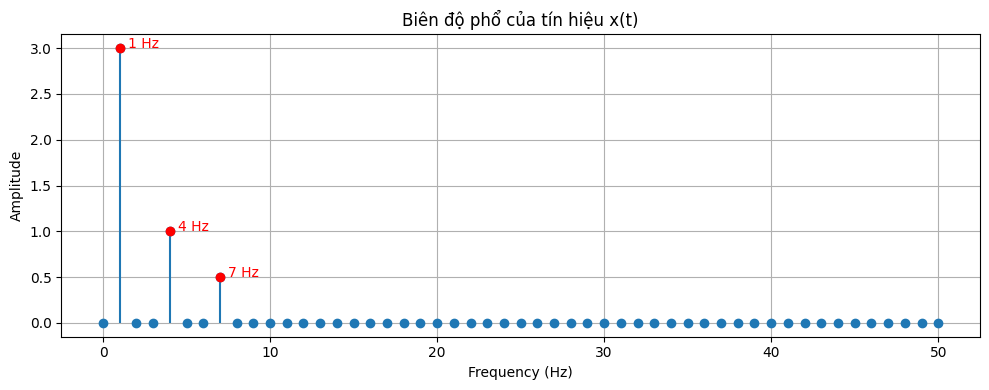

In [16]:
fs = 100
T = 1
t = np.linspace(0, T, int(fs*T), endpoint=False)
N = len(t)
x1 = 3 * np.sin(2 * np.pi * 1 * t)
x2 = 1 * np.sin(2 * np.pi * 4 * t)
x3 = 0.5 * np.sin(2 * np.pi * 7 * t)

x = x1 + x2 + x3

X = dft(x)
f = np.arange(0, N//2 + 1) * fs / N

magnitude = np.abs(X)[:N//2 + 1] / (N/2)

plt.figure(figsize=(10, 4))
plt.stem(f, magnitude, basefmt=" ")
plt.title('Biên độ phổ của tín hiệu x(t)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

for freq in [1, 4, 7]:
    idx = int(freq * N / fs)
    plt.plot(f[idx], magnitude[idx], 'ro')
    plt.text(f[idx]+0.5, magnitude[idx], f'{freq} Hz', color='red')

plt.tight_layout()
plt.show()

## Bài 2

## a)

In [28]:
x = np.loadtxt('/content/ex2-data.txt')
print(x)
print(x.shape)

[  1.21886832  -2.58857957   6.10079602   8.30280482  -1.94779204
   1.80192394   8.48404358   7.45270026   9.16028493   6.07903658
  13.02297066  12.38519164   9.07258369  12.63579293   9.12345372
   2.78063161   6.52881579  -0.03715695   6.00405703   0.96908715
  -0.86686923  -4.08546429   2.38947944  -4.13301113  -6.09335799
  -6.48606358  -3.46566136  -4.46435322  -4.42070603  -4.31477425
   2.72875646  -7.11423858  -7.06125696  -7.68948234  -1.31880894
   1.42947834  -2.83050594  -5.03657654  -4.31432531   2.18300263
   3.06867103   2.68627421  -1.83744755   1.95229732   1.57809292
   1.96812413   4.46594405   1.68112383   3.2469725    0.50543984
   1.07760539   2.1382406   -6.4941263   -2.17113784  -2.92935243
  -3.67053137  -2.18175314   5.04156735  -4.14625732   3.55558152
  -6.58092292  -0.63078662   1.9907491    4.36690445   5.57558752
   6.61169985   2.72107695   2.88493573   8.69669459   4.91533544
   0.85504338   1.54343625   2.34401638   7.7725476    5.92895917
   7.51261

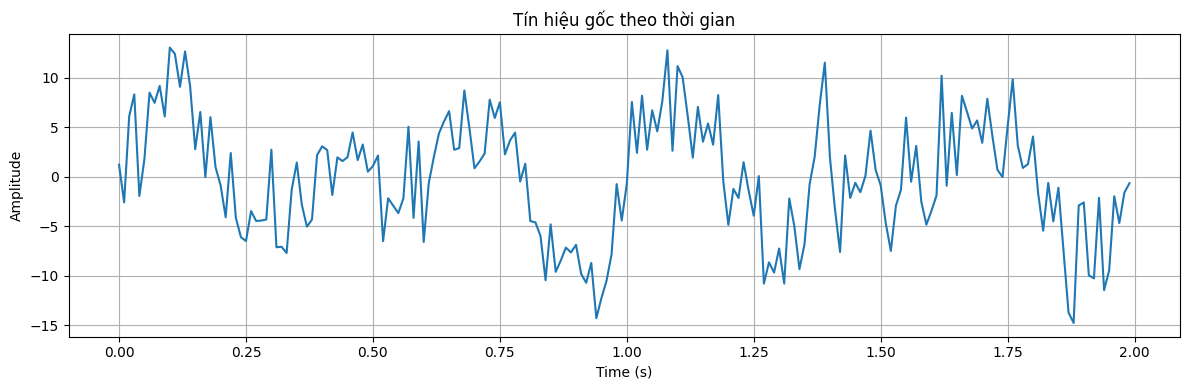

In [29]:
fs = 100
N = len(x)
T = N / fs

t = np.linspace(0, T, N, endpoint=False)

plt.figure(figsize=(12, 4))
plt.plot(t, x)
plt.title('Tín hiệu gốc theo thời gian')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

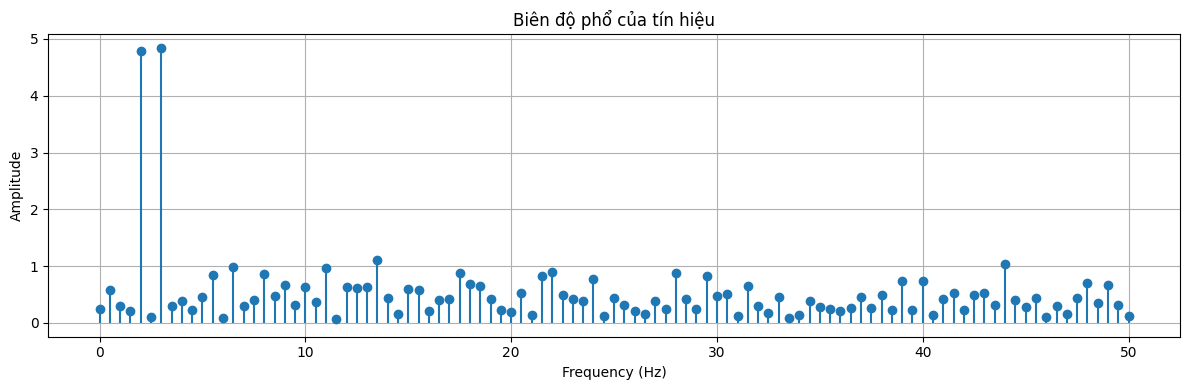

In [30]:
X = dft(x)

f = np.arange(0, N//2 + 1) * fs / N

magnitude = np.abs(X)[:N//2 + 1] / (N/2)

plt.figure(figsize=(12, 4))
plt.stem(f, magnitude, basefmt=" ")
plt.title('Biên độ phổ của tín hiệu')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

## b)

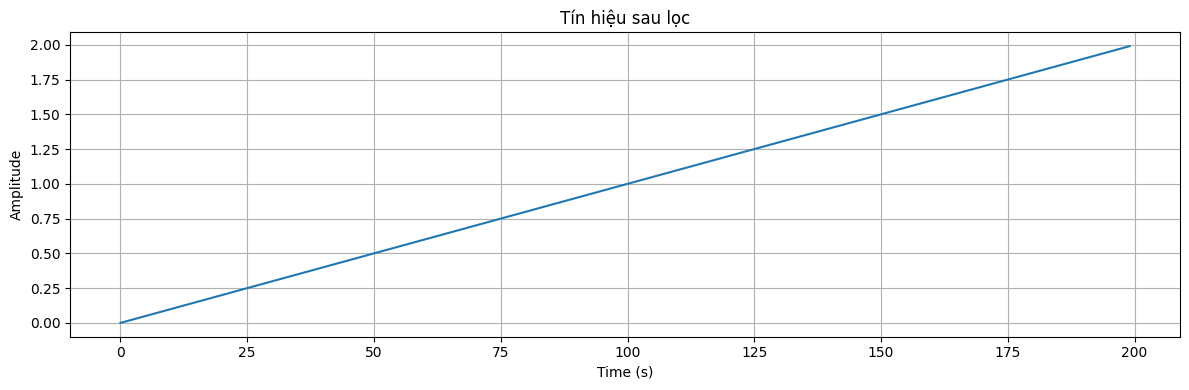

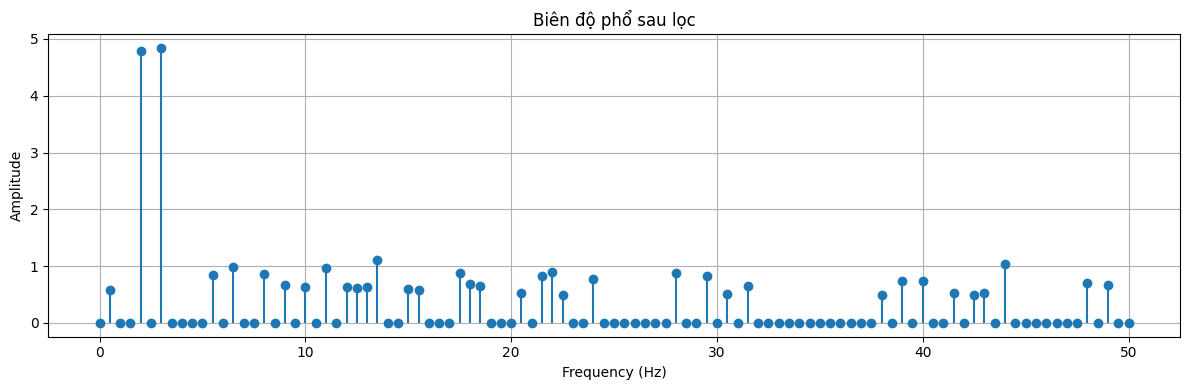

In [36]:
threshold = 0.1 * np.max(magnitude)

X_filtered = X.copy()
magnitude_filtered = np.abs(X_filtered) / (N/2)
X_filtered[magnitude_filtered < threshold] = 0

x_reconstructed = idft(X_filtered)

plt.figure(figsize=(12, 4))
plt.plot(t)
plt.title('Tín hiệu sau lọc')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

magnitude_filtered_plot = np.abs(X_filtered)[:N//2 + 1] / (N/2)

plt.figure(figsize=(12, 4))
plt.stem(f, magnitude_filtered_plot, basefmt=" ")
plt.title('Biên độ phổ sau lọc')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

1. Compare noise and smoothness of signal before and after filtering
- Before filtering: Noise appears in the form of small curvation, not smooth, stacked on top of original signal. Alot of oscillation, up and downs
- After filtering: Signal becomes much smoother, more stable.
2. Decreasing of unwanted frequency components - amplitude
- Before filtering: There are still small, little frequency components. Those components are usually high-frequency noise, small errors
- After filtering: Remains only strong frequency. Makes the signal cleaner

# Ex3

In [37]:
def fft(x):
  N = len(x)
  if N == 1:
    return x
  X_even = fft(x[::2])
  X_odd = fft(x[1::2])
  factor = np.exp(-2j * np.pi * np.arange(N) // 2)
  return np.concat([X_even + factor[:N // 2] * X_odd,
                   X_even + factor[N // 2:] * X_odd])

In [38]:
def ifft(X):
  return np.conjugate(fft(np.conjugate(X))) / len(X)